# Hex Grid Graph Examples

This notebook demonstrates the `HexGridGraph` class for creating phasic graphs on hexagonal grids constrained by shapefile boundaries.

## Setup

In [1]:
# Configure phasic before import
import phasic
#phasic.configure(ffi=False)

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import sys


# Import hex grid module
sys.path.insert(0, '..')
from hex_grid_graph import HexGridGraph

%matplotlib inline
#plt.rcParams['figure.dpi'] = 100

import vscodenb
vscodenb.set_vscode_theme()
from vscodenb import vscode_theme as theme

## Helper Function: Create Synthetic Shapefile

In [2]:
def create_circular_boundary(path: str, radius: float = 0.5):
    """Create a circular shapefile for testing."""
    circle = Point(0, 0).buffer(radius)
    gdf = gpd.GeoDataFrame({'geometry': [circle]}, crs='EPSG:4326')
    gdf.to_file(path)
    return path

## Example 1: Basic Hex Grid Visualization

Create and visualize a basic hexagonal grid within a circular boundary.

Created hex grid with 441 vertices


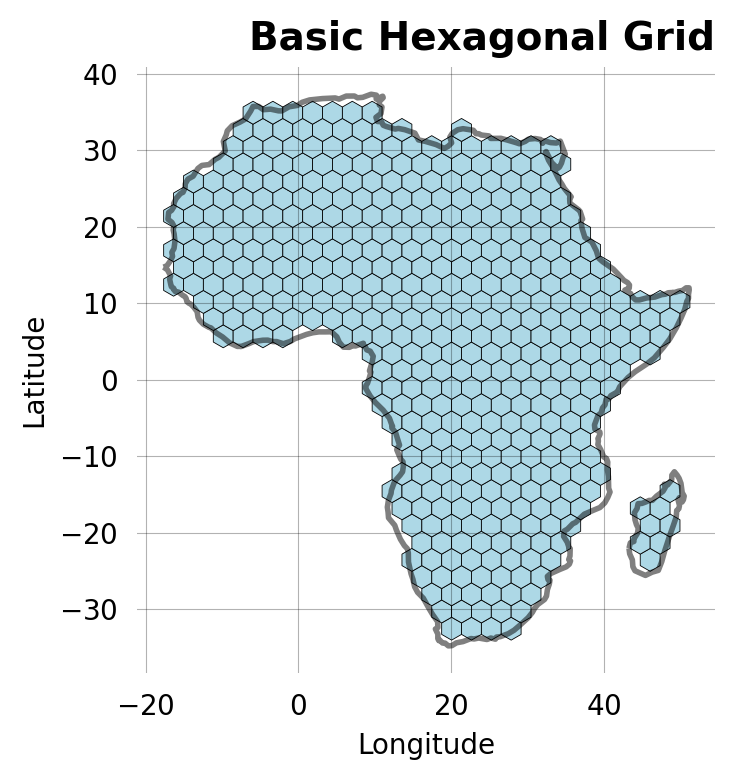

In [3]:
# # Create boundary
# shapefile_path = '/tmp/circle.shp'
# create_circular_boundary(shapefile_path, radius=0.5)
# # Create hex grid
# hex_graph = HexGridGraph(shapefile_path, hex_size=0.05)


url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)
africa = world[world['CONTINENT'] == 'Africa'].dissolve()
# Save Africa shapefile
shapefile_path = '/tmp/africa.shp'
africa.to_file(shapefile_path)
hex_graph = HexGridGraph(shapefile_path, hex_size=1.5)



print(f"Created hex grid with {len(hex_graph.hex_centers)} vertices")

# Plot empty grid
fig, ax = hex_graph.plot_hex_grid(title='Basic Hexagonal Grid')
plt.tight_layout()
plt.show()

## Example 2: Random Walk with Cumulated Occupancy

Simulate a random walk on the hex grid and visualize cumulated occupancy over time.

In [4]:
# Define random walk callback
def random_walk_callback(state, hex_graph):
    """Equal rate to all neighboring hex cells."""
    vertex_idx = int(state[0])
    neighbors = hex_graph.get_neighbors(vertex_idx)
    
    if not neighbors:
        return []
    
    rate = 1.0
    transitions = []
    for neighbor_idx in neighbors:
        next_state = state.copy()
        next_state[0] = neighbor_idx
        transitions.append((next_state, rate, []))
    
    return transitions

# Build graph starting from center vertex
hex_graph_rw = HexGridGraph(shapefile_path, hex_size=1.5)
center_vertex = hex_graph_rw.get_center_vertex()
print(f"Center vertex: {center_vertex}")

hex_graph_rw.build_graph(
    callback=random_walk_callback,
    state_length=1,
    parameterized=False,
    start_vertex=center_vertex  # Start probability mass at center
)

print(f"Built graph with {hex_graph_rw.graph.vertices_length()} vertices")

Center vertex: 180


Built graph with 442 vertices


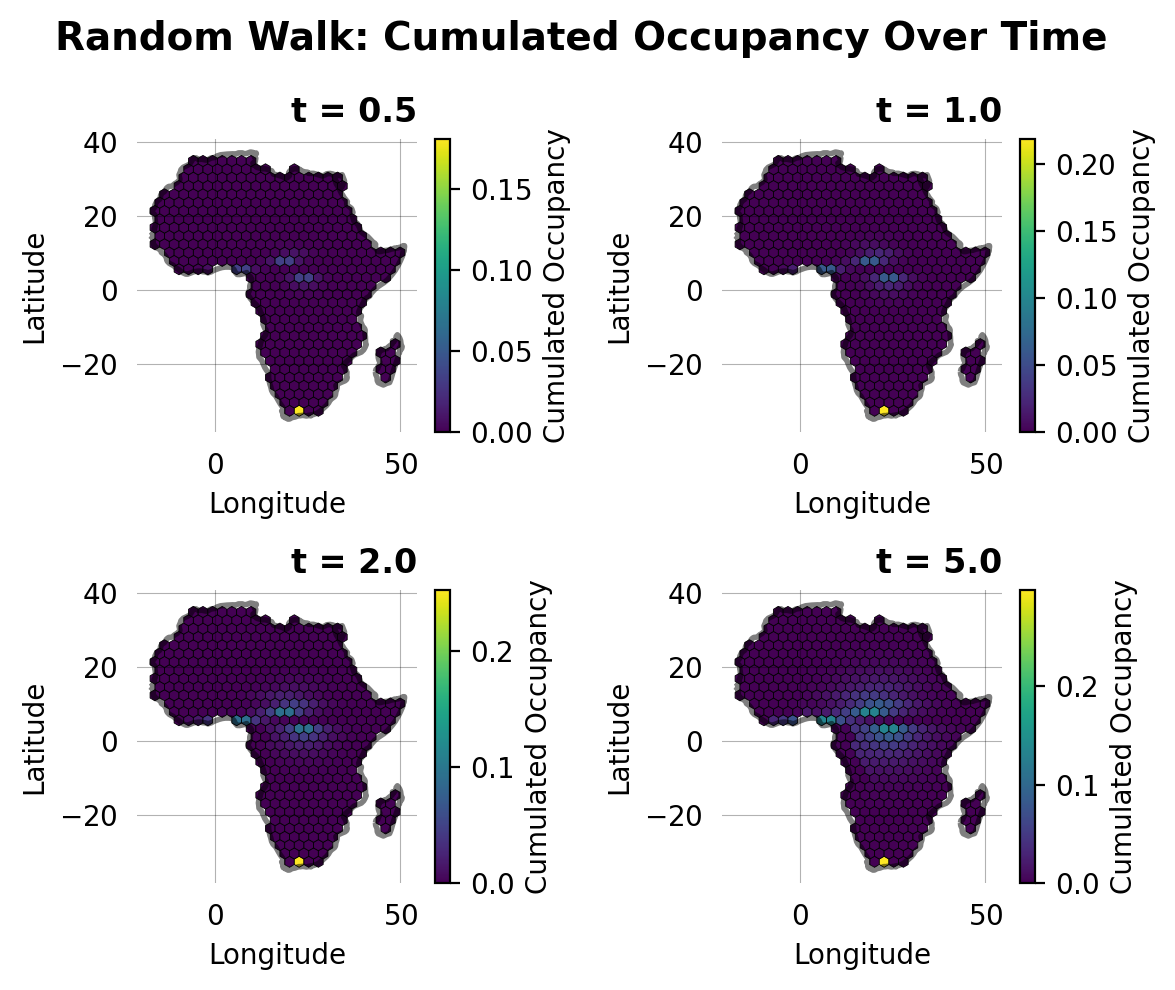

In [5]:
# Plot cumulated occupancy at different times
times = [0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

for i, t in enumerate(times):
    occupancy = np.array(hex_graph_rw.graph.accumulated_occupancy(t))
    
    # Create plot on subplot
    ax = axes[i]
    hex_graph_rw.gdf.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.5)
    
    from matplotlib.patches import RegularPolygon
    from matplotlib.collections import PatchCollection
    
    patches = []
    for lon, lat in hex_graph_rw.hex_centers:
        hex_patch = RegularPolygon(
            (lon, lat),
            numVertices=6,
            radius=hex_graph_rw.hex_size,
            orientation=0  # Pointy-top hexagon
        )
        patches.append(hex_patch)
    
    pc = PatchCollection(patches, cmap='viridis', linewidths=0.3, edgecolors='black')
    pc.set_array(occupancy)
    ax.add_collection(pc)
    
    ax.set_aspect('equal')
    ax.set_title(f't = {t:.1f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    plt.colorbar(pc, ax=ax, label='Cumulated Occupancy')

plt.suptitle('Random Walk: Cumulated Occupancy Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Example 3: Directional Bias

Create a movement model with directional bias (preferring northward movement).

In [6]:
# Define biased walk callback
def northward_bias_callback(state, hex_graph):
    """Higher rate for northward movement."""
    vertex_idx = int(state[0])
    neighbors = hex_graph.get_neighbors(vertex_idx)
    
    if not neighbors:
        return []
    
    current_x, current_y = hex_graph.hex_centers[vertex_idx]
    transitions = []
    
    for neighbor_idx in neighbors:
        next_x, next_y = hex_graph.hex_centers[neighbor_idx]
        
        # Bias based on direction
        if next_y > current_y:
            rate = 3.0  # Northward
        elif next_y < current_y:
            rate = 0.5  # Southward
        else:
            rate = 1.0  # East/West
        
        next_state = state.copy()
        next_state[0] = neighbor_idx
        transitions.append((next_state, rate, []))
    
    return transitions

# Build biased graph
hex_graph_biased = HexGridGraph(shapefile_path, hex_size=1.5)
hex_graph_biased.build_graph(
    callback=northward_bias_callback,
    state_length=1
)

# Plot cumulated occupancy
fig, ax = hex_graph_biased.plot_cumulated_occupancy(
    time=1.0,
    # cmap='coolwarm',
    cmap='viridis',
    title='Northward-Biased Movement at t=1.0'
)
plt.tight_layout()
plt.show()

AttributeError: 'HexGridGraph' object has no attribute 'plot_cumulated_occupancy'

## Example 4: Connectivity Analysis

Visualize the connectivity structure of the hex grid.

Total vertices: 441
Average neighbors: 5.51
Min neighbors: 1
Max neighbors: 6


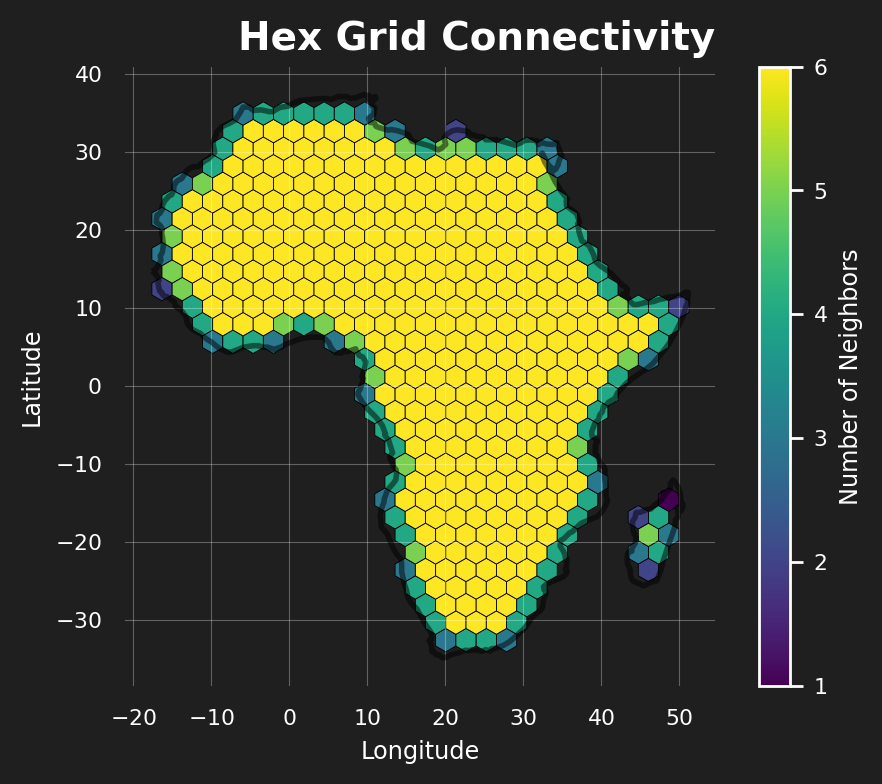

In [ ]:
# Analyze neighbor counts
hex_graph_conn = HexGridGraph(shapefile_path, hex_size=1.5)

n_vertices = len(hex_graph_conn.hex_centers)
neighbor_counts = np.zeros(n_vertices)

for vertex_idx in range(n_vertices):
    neighbors = hex_graph_conn.get_neighbors(vertex_idx)
    neighbor_counts[vertex_idx] = len(neighbors)

print(f"Total vertices: {n_vertices}")
print(f"Average neighbors: {neighbor_counts.mean():.2f}")
print(f"Min neighbors: {int(neighbor_counts.min())}")
print(f"Max neighbors: {int(neighbor_counts.max())}")

# Plot connectivity
fig, ax = hex_graph_conn.plot_hex_grid(
    values=neighbor_counts,
    # cmap='plasma',
    cmap='viridis',
    title='Hex Grid Connectivity',
    colorbar_label='Number of Neighbors'
)
plt.tight_layout()
plt.show()

## Example 5: State Probability Evolution

Visualize state probabilities over time. The probability mass starts at the center vertex and diffuses outward through the hex grid.

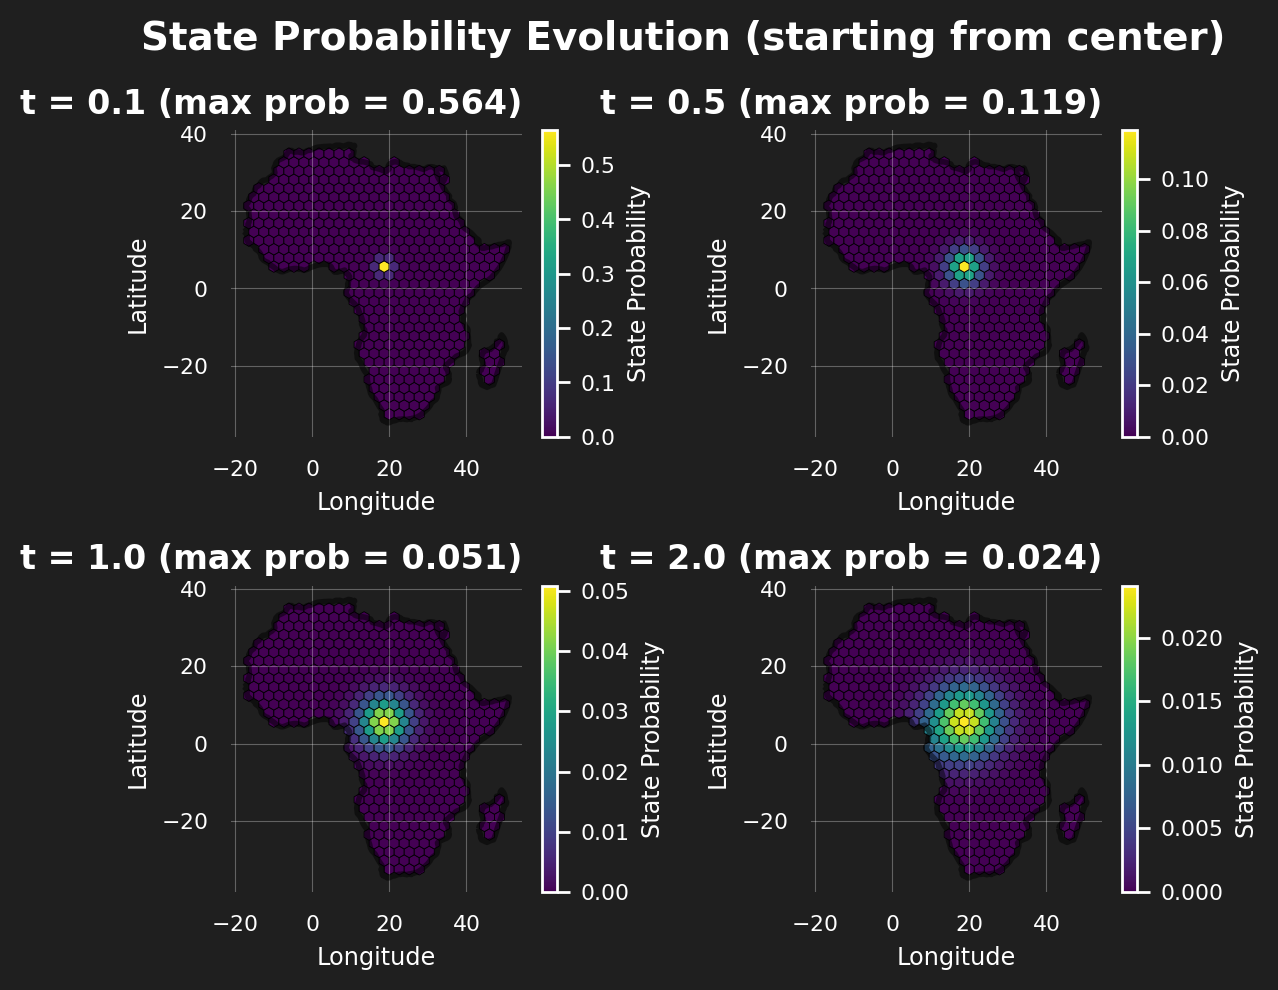

In [ ]:
# State probabilities at different times (graph already starts from center)
times = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

for i, t in enumerate(times):
    # Get state probabilities mapped to hex cell indices
    probabilities = hex_graph_rw.get_state_probabilities(t)
    
    # Plot
    ax = axes[i]
    hex_graph_rw.gdf.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.5)
    
    from matplotlib.patches import RegularPolygon
    from matplotlib.collections import PatchCollection
    
    patches = []
    for lon, lat in hex_graph_rw.hex_centers:
        hex_patch = RegularPolygon(
            (lon, lat),
            numVertices=6,
            radius=hex_graph_rw.hex_size,
            orientation=0  # Pointy-top hexagon
        )
        patches.append(hex_patch)
    
    pc = PatchCollection(patches, 
                        #  cmap='hot', 
                         cmap='viridis', 
                         linewidths=0.3, edgecolors='black')
    pc.set_array(probabilities)
    pc.set_clim(0, max(probabilities) if max(probabilities) > 0 else 1)
    ax.add_collection(pc)
    
    ax.set_aspect('equal')
    ax.set_title(f't = {t:.1f} (max prob = {max(probabilities):.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    plt.colorbar(pc, ax=ax, label='State Probability')

plt.suptitle('State Probability Evolution (starting from center)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Example 5b: Animated State Probability Diffusion

Create an animation showing how 

<!-- state probability  -->
occupancy

spreads from the center vertex over time using `FuncAnimation`.

In [ ]:
from matplotlib.animation import FuncAnimation
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
from IPython.display import HTML

# Pre-compute state probabilities for all time points
n_frames = 40
times_anim = np.linspace(0.01, 50.0, n_frames)
n_vertices = len(hex_graph_rw.hex_centers)

print(f"Computing state probabilities for {n_frames} frames...")
prob_over_time = np.zeros((n_frames, n_vertices))

for t_idx, t in enumerate(times_anim):
    # prob_over_time[t_idx] = hex_graph_rw.get_state_probabilities(t)
    prob_over_time[t_idx] = hex_graph_rw.get_cumulated_occupancies(t)
    

print(f"Done! Max probability: {prob_over_time.max():.4f}")

# Setup figure
fig, ax = plt.subplots(figsize=(5, 5))

# Plot boundary
hex_graph_rw.gdf.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.5)

# Create hexagon patches (pointy-top orientation)
patches = []
for lon, lat in hex_graph_rw.hex_centers:
    hex_patch = RegularPolygon(
        (lon, lat),
        numVertices=6,
        radius=hex_graph_rw.hex_size,
        orientation=0  # Pointy-top hexagon
    )
    patches.append(hex_patch)

# Create patch collection with thin borders
pc = PatchCollection(patches, cmap='viridis', linewidths=0.3, edgecolors='black')

pc.set_clim(0, prob_over_time.max() if prob_over_time.max() > 0 else 1)
# pc.set_clim(0, 0.01)

ax.add_collection(pc)

# Add colorbar
cbar = plt.colorbar(pc, ax=ax, shrink=0.8)
cbar.set_label('State Probability', fontsize=12)

# Configure axes
ax.set_aspect('equal')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)

# Title (will be updated in animation)
title = ax.set_title('State Probability Diffusion: t = 0.00', fontsize=12, fontweight='bold')

# Animation update function
def update(frame):
    pc.set_array(prob_over_time[frame])
    title.set_text(f'State Probability Diffusion: t = {times_anim[frame]:.2f}')
    return pc, title

# Create animation
anim = FuncAnimation(
    fig, 
    update, 
    frames=n_frames,
    interval=100,  # 100ms per frame
    blit=True
)

plt.tight_layout()
plt.close()
# Display animation in notebook
HTML(anim.to_jshtml())

Computing state probabilities for 40 frames...
Done! Max probability: 0.4566


In [ ]:
# Optional: Save animation as GIF file
# Requires pillow: pip install pillow

try:
    anim.save('state_probability_diffusion.gif', writer='pillow', fps=10)
    print("Animation saved to: state_probability_diffusion.gif")
except Exception as e:
    print(f"Could not save GIF (install pillow if needed): {e}")

Animation saved to: state_probability_diffusion.gif


## Example 6: Africa Hex Grid

Create a hex grid covering the African continent using Natural Earth data.

Created hex grid with 441 vertices


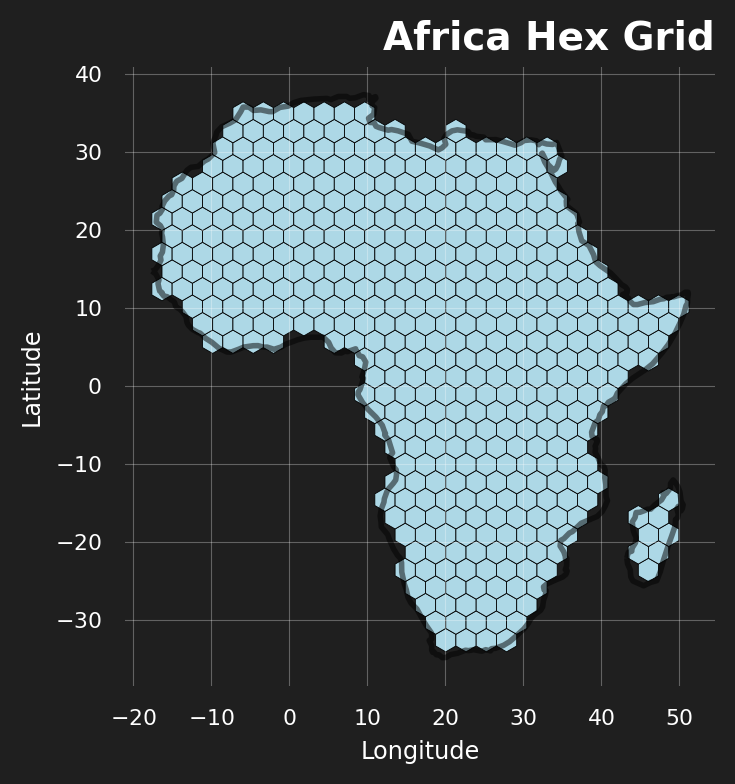

In [ ]:
# Download countries data from Natural Earth and extract Africa
url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)
africa = world[world['CONTINENT'] == 'Africa'].dissolve()

# Save Africa shapefile
africa_path = '/tmp/africa.shp'
africa.to_file(africa_path)

# Create hex grid over Africa (hex_size in degrees, ~2 degrees ≈ 220km at equator)
hex_graph_africa = HexGridGraph(africa_path, hex_size=1.5)
print(f"Created hex grid with {len(hex_graph_africa.hex_centers)} vertices")

# Plot basic hex grid
fig, ax = hex_graph_africa.plot_hex_grid(title='Africa Hex Grid')
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Basic hex grid creation** within shapefile boundaries
2. **Random walk simulation** with cumulated occupancy visualization
3. **Directional bias** in movement models
4. **Connectivity analysis** of hex grid structure  
5. **State probability evolution** - static snapshots and **animated diffusion** using `FuncAnimation`
6. **Africa hex grid** - real-world geographic example using Natural Earth data

The `HexGridGraph` class provides a flexible framework for spatial phase-type distribution models on hexagonal grids.

## Summary

This notebook demonstrated:

1. **Basic hex grid creation** within shapefile boundaries
2. **Random walk simulation** with cumulated occupancy visualization
3. **Directional bias** in movement models
4. **Connectivity analysis** of hex grid structure  
5. **State probability evolution** - static snapshots and **animated diffusion** using `FuncAnimation`
6. **Parameterized models** for SVGD inference

The `HexGridGraph` class provides a flexible framework for spatial phase-type distribution models on hexagonal grids.